# 📰 Klasifikasi Berita Hoaks vs Valid (Bahasa Indonesia) — Support Vector Machine

**Notebook production-ready** untuk membangun, mengevaluasi, dan men-*deploy* model klasifikasi berita
hoaks berbahasa Indonesia menggunakan **TF-IDF + Support Vector Machine (SVM)**.

Notebook ini dirancang agar:

* **Akurat** — melalui *hyperparameter tuning* (`GridSearchCV`) pada TF-IDF maupun SVM.
* **Tidak *overfitting*** — dilengkapi analisis *train vs test*, *cross-validation*, dan *learning curve*.
* **Reusable** — seluruh alur dibungkus fungsi & `Pipeline` scikit-learn.
* **Mudah diperbarui** — semua file CSV di folder dataset dibaca **otomatis** (`glob`). Menambah dataset
  hasil *scraping* baru cukup dengan menaruh file `.csv` di folder yang sama lalu menjalankan ulang
  notebook — **tanpa mengubah satu baris kode pun**.

---

### 🧭 Peta Alur Notebook
1. Import Library · 2. Load Dataset (otomatis) · 3. EDA · 4. Data Cleaning · 5. Text Preprocessing (Sastrawi)
· 6. Feature Engineering (TF-IDF) · 7. Train/Test Split · 8. Penanganan *Imbalance* · 9. Hyperparameter Tuning
· 10. Training · 11. Evaluasi · 12. Analisis *Overfitting* · 13. Cross-Validation · 14. Learning Curve
· 15. Feature Importance · 16. Simpan Model · 17. `predict_news()` · 18. Pipeline Reusable
· 19–20. Update Dataset Otomatis & `append_new_dataset()` · 21. Visualisasi · 22. Kesimpulan

## 🎓 Teori Singkat: Mengapa SVM + TF-IDF untuk Deteksi Hoaks?

**Support Vector Machine (SVM)** mencari *hyperplane* pemisah antar-kelas dengan **margin semaksimal
mungkin**. Titik-titik terdekat yang menentukan margin disebut *support vectors*. Untuk data yang tidak
terpisah linear, SVM memakai **kernel** (mis. RBF) untuk memetakan data ke ruang berdimensi lebih tinggi.

**Kenapa cocok untuk teks?**
* **Efektif di dimensi tinggi** — representasi TF-IDF menghasilkan ribuan fitur; SVM tetap tangguh
  bahkan ketika jumlah fitur > jumlah sampel.
* **Tahan *overfitting*** karena prinsip *maximum margin* (regularisasi lewat parameter `C`).
* **Kernel linear** umumnya **juara** untuk teks (data teks cenderung linear-separable di ruang TF-IDF)
  sekaligus **interpretable** — bobot `coef_` bisa dibaca sebagai kata paling menentukan tiap kelas.

**Kenapa TF-IDF?** *Term Frequency–Inverse Document Frequency* memberi bobot tinggi pada kata yang sering
muncul di suatu dokumen namun jarang di korpus keseluruhan — sehingga kata generik ("yang", "dan") ditekan
dan kata pembeda ("hoaks", "beredar", "klaim") ditonjolkan. Ringan, cepat, dan sangat kuat sebagai
*baseline* teks — pasangan alami untuk SVM linear.

## 1️⃣ Import Library
Semua dependensi dikumpulkan di sini. Bila ada yang belum terpasang, jalankan sel instalasi (cukup sekali).

In [2]:
# Jalankan SEKALI bila library belum terpasang, lalu boleh dikomentari kembali.
# !pip install -q pandas numpy matplotlib seaborn scikit-learn nltk Sastrawi joblib

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os, re, glob, string, hashlib, warnings
from pathlib import Path

# ── Third-party ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold, learning_curve)
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay)

# ── NLP: NLTK + Sastrawi (Bahasa Indonesia) ─────────────────────────────────
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ── Konfigurasi tampilan ─────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 120)

# Unduh resource NLTK (aman dijalankan berulang)
for _pkg in ["stopwords", "punkt", "punkt_tab"]:
    try:
        nltk.download(_pkg, quiet=True)
    except Exception as _e:
        print(f"[NLTK] gagal unduh {_pkg}: {_e}")

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


## ⚙️ Konfigurasi Global
Satu tempat untuk **semua** pengaturan. `RANDOM_STATE = 42` dipakai konsisten agar hasil **reproducible**.

> **Catatan performa penting.** *Stemmer* Sastrawi relatif lambat. Notebook memakai **cache kata**
> (tiap kata di-*stem* sekali, disimpan ke disk) dan **cache dataframe terproses**. Konsekuensinya:
> **run pertama lambat** (bisa puluhan menit untuk puluhan ribu berita) namun **run berikutnya instan**
> selama data tidak berubah.

In [2]:
# ── Path ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("Cleaned Dataset V3")   # folder berisi CSV; semua *.csv dibaca OTOMATIS
MODELS_DIR = Path("models")               # tempat model & cache
MODELS_DIR.mkdir(exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42

# ── Kolom yang dideteksi otomatis (tak perlu diedit saat menambah data) ──────
LABEL_CANDIDATES = ["label", "hoax", "is_hoax", "hoaks", "kelas", "class", "target"]
TEXT_CANDIDATES  = ["clean_text", "text", "narasi", "isi", "content", "berita", "body"]
TITLE_CANDIDATES = ["judul", "title", "headline", "judul_berita"]

# ── Flag pemrosesan ──────────────────────────────────────────────────────────
USE_STEMMING  = True   # Sastrawi stemming (set False untuk eksperimen cepat)
MIN_TOKEN_LEN = 3      # buang token < 3 huruf

# ── Batas subset saat TUNING (agar GridSearch RBF tetap tractable) ───────────
# Model FINAL tetap dilatih pada SELURUH data latih. Subset hanya untuk pencarian
# hyperparameter yang mahal (SVC-RBF berskala ~kuadratik terhadap jumlah sampel).
TUNE_MAX_SAMPLES = 6000   # set None untuk memakai seluruh data latih saat tuning

# ── Path cache ───────────────────────────────────────────────────────────────
STEM_CACHE_PATH = MODELS_DIR / "stem_cache.pkl"
PROC_CACHE_PATH = MODELS_DIR / "processed_data.pkl"

print(f"DATA_DIR   : {DATA_DIR.resolve()}")
print(f"MODELS_DIR : {MODELS_DIR.resolve()}")
print(f"RANDOM_STATE = {RANDOM_STATE} | USE_STEMMING = {USE_STEMMING}")

DATA_DIR   : D:\Data Science\Cleaned Dataset V3
MODELS_DIR : D:\Data Science\models
RANDOM_STATE = 42 | USE_STEMMING = True


## 2️⃣ Load Dataset — Otomatis & *Future-proof*

`load_dataset()`:
* Membaca **semua** `*.csv` di `DATA_DIR` via `glob` (tanpa menuliskan nama file satu per satu).
* **Mendeteksi otomatis** kolom label/teks/judul — dataset dengan nama kolom berbeda (mis. `label` vs
  `hoax`) tetap terbaca.
* **Menormalkan label** ke biner standar: **`1 = Hoaks`, `0 = Valid`** (mendukung nilai numerik maupun teks).
* Menggabungkan semuanya menjadi satu `DataFrame`.

> Menambah `cnn_cleaned.csv`, `tempo_cleaned.csv`, dll. cukup taruh di folder ini lalu jalankan ulang —
> **tak ada kode yang perlu diedit**.

In [3]:
def _pick_column(columns, candidates):
    # Kembalikan kolom pertama pada `candidates` yang ada di `columns` (case-insensitive).
    lookup = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lookup:
            return lookup[cand.lower()]
    return None


def normalize_label(value):
    # Petakan berbagai representasi label -> biner: 1 = Hoaks, 0 = Valid.
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    hoax_set  = {"1", "hoax", "hoaks", "fake", "palsu", "salah", "disinformasi", "misinformasi"}
    valid_set = {"0", "valid", "real", "fakta", "benar", "asli", "true_news"}
    if s in hoax_set:
        return 1
    if s in valid_set:
        return 0
    try:                       # tangani "1.0", "0.0", dsb.
        return int(float(s))
    except ValueError:
        return np.nan


def _load_single_csv(path):
    # Baca satu CSV -> DataFrame kolom standar [title, text, label, source].
    raw = pd.read_csv(path)
    label_col = _pick_column(raw.columns, LABEL_CANDIDATES)
    text_col  = _pick_column(raw.columns, TEXT_CANDIDATES)
    title_col = _pick_column(raw.columns, TITLE_CANDIDATES)

    if label_col is None or text_col is None:
        raise ValueError(
            f"'{path.name}' tidak punya kolom label/teks yang dikenali. "
            f"Kolom tersedia: {list(raw.columns)}"
        )

    out = pd.DataFrame()
    out["title"]  = raw[title_col].astype(str) if title_col else ""
    out["text"]   = raw[text_col].astype(str)
    out["label"]  = raw[label_col].map(normalize_label)
    out["source"] = path.stem
    return out


def load_dataset(folder=DATA_DIR, verbose=True):
    # Baca & gabungkan SEMUA CSV di `folder` -> satu DataFrame ternormalisasi.
    folder = Path(folder)
    files = sorted(folder.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"Tidak ada file .csv di {folder.resolve()}")

    frames = []
    for f in files:
        part = _load_single_csv(f)
        frames.append(part)
        if verbose:
            print(f"  • {f.name:<32} {len(part):>7,} baris  "
                  f"(hoaks={int((part['label']==1).sum()):>6,}, "
                  f"valid={int((part['label']==0).sum()):>6,})")

    data = pd.concat(frames, ignore_index=True)
    before = len(data)
    data = data.dropna(subset=["label", "text"]).copy()
    data["label"] = data["label"].astype(int)
    data["text"]  = data["text"].astype(str)
    if verbose:
        print(f"\n✅ {len(files)} file digabung → {before:,} baris "
              f"({before - len(data):,} dibuang karena label/teks kosong).")
    return data.reset_index(drop=True)


df = load_dataset()
df.head()

  • antaranews_cleaned_v3.csv          4,066 baris  (hoaks=     0, valid= 4,066)
  • detik_cleaned_v3.csv               3,576 baris  (hoaks=     0, valid= 3,576)
  • kompas_cleaned_v3.csv              4,499 baris  (hoaks=     0, valid= 4,499)
  • tbh_cleaned_v3.csv                11,816 baris  (hoaks=11,816, valid=     0)

✅ 4 file digabung → 23,957 baris (0 dibuang karena label/teks kosong).


,title,text,label,source
0,Menhan sebut keberadaan YTP akan bantu kehidupan bantu rakyat,menteri pertahanan sjafrie sjamsoeddin menilai kehadiran batalyon teritorial pembangunan ytp akan sangat membantu ke...,0,antaranews_cleaned_v3
1,AMPG apresiasi respons cepat pemerintah evaluasi sistem perkeretaapian,"pengurus pusat angkatan muda partai golkar ampg mengapresiasi langkah cepat pemerintah, termasuk kehadiran langsung ...",0,antaranews_cleaned_v3
2,Prabowo ultimatum pejabat-ilmuwan tak patriotik untuk keluar barisan,presiden prabowo subianto memberikan ultimatum keras kepada pejabat maupun intelektual yang tidak memiliki jiwa patr...,0,antaranews_cleaned_v3
3,Mendagri apresiasi peran TNI jaga inflasi dan stabilitas nasional,menteri dalam negeri mendagri muhammad tito karnavian mengapresiasi peran aktif jajaran tentara nasional indonesia t...,0,antaranews_cleaned_v3
4,Anggota DPR: Kecelakaan bus haji pengingat untuk awasi agenda tambahan,anggota komisi viii dpr ri dini rahmania mengatakan bahwa kecelakaan yang dialami bus jamaah haji saat perjalanan wi...,0,antaranews_cleaned_v3


## 3️⃣ Exploratory Data Analysis (EDA)
Memahami data sebelum memodelkan: struktur, *missing value*, duplikat, distribusi label, dan panjang berita.

In [4]:
print("── Info dataset ──")
df.info()
print("\nShape :", df.shape)

── Info dataset ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23957 entries, 0 to 23956
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23957 non-null  object
 1   text    23957 non-null  object
 2   label   23957 non-null  int32 
 3   source  23957 non-null  object
dtypes: int32(1), object(3)
memory usage: 655.2+ KB

Shape : (23957, 4)


In [5]:
print("Missing value per kolom:")
print(df.isna().sum())

dup = df.duplicated(subset=["title", "text"]).sum()
print(f"\nDuplikat (judul+teks) : {dup:,}")

print("\nDistribusi label (0=Valid, 1=Hoaks):")
print(df["label"].value_counts().rename({0: "Valid", 1: "Hoaks"}))
print("\nProporsi:")
print((df["label"].value_counts(normalize=True) * 100).round(2).rename({0: "Valid", 1: "Hoaks"}))

print("\nSumber data:")
print(df["source"].value_counts())

Missing value per kolom:
title     0
text      0
label     0
source    0
dtype: int64

Duplikat (judul+teks) : 3

Distribusi label (0=Valid, 1=Hoaks):
label
Valid    12141
Hoaks    11816
Name: count, dtype: int64

Proporsi:
label
Valid    50.68
Hoaks    49.32
Name: proportion, dtype: float64

Sumber data:
source
tbh_cleaned_v3           11816
kompas_cleaned_v3         4499
antaranews_cleaned_v3     4066
detik_cleaned_v3          3576
Name: count, dtype: int64


In [6]:
# Panjang berita (jumlah kata) sebagai fitur eksplorasi
df["n_words"] = df["text"].str.split().apply(len)
print(df.groupby(df["label"].map({0: "Valid", 1: "Hoaks"}))["n_words"]
        .describe()[["mean", "50%", "min", "max"]].round(1))

        mean    50%   min    max
label                           
Hoaks   61.3   48.0  10.0  670.0
Valid  106.1  112.0  10.0  155.0


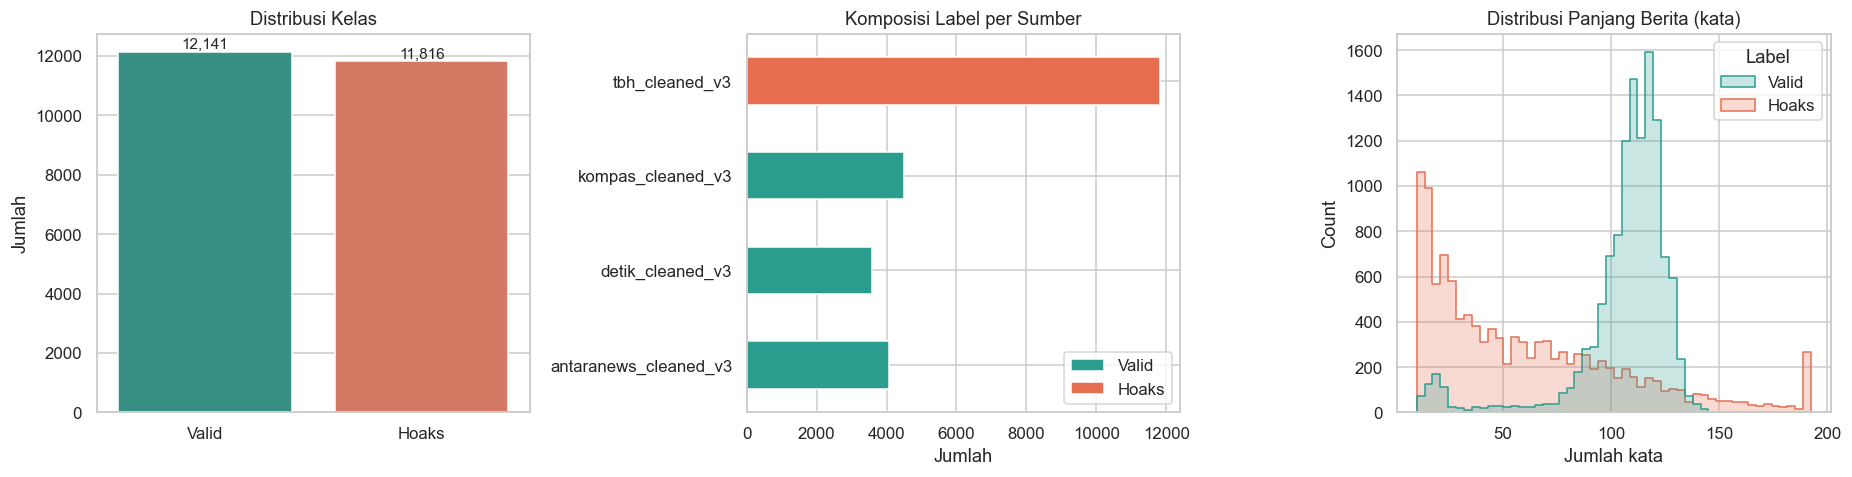

In [7]:
# Visualisasi ringkas: distribusi kelas, per sumber, dan panjang berita
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

order = [0, 1]
sns.countplot(x=df["label"].map({0: "Valid", 1: "Hoaks"}),
              order=["Valid", "Hoaks"], palette=["#2a9d8f", "#e76f51"], ax=ax[0])
ax[0].set_title("Distribusi Kelas"); ax[0].set_xlabel(""); ax[0].set_ylabel("Jumlah")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}",
                   (p.get_x() + p.get_width()/2, p.get_height()),
                   ha="center", va="bottom", fontsize=10)

src = df.groupby(["source", "label"]).size().unstack(fill_value=0)
src.columns = ["Valid" if c == 0 else "Hoaks" for c in src.columns]
src.plot(kind="barh", stacked=True, color=["#2a9d8f", "#e76f51"], ax=ax[1])
ax[1].set_title("Komposisi Label per Sumber"); ax[1].set_ylabel(""); ax[1].set_xlabel("Jumlah")

clip = df["n_words"].clip(upper=df["n_words"].quantile(0.99))
sns.histplot(data=pd.DataFrame({"n_words": clip, "Label": df["label"].map({0:"Valid",1:"Hoaks"})}),
             x="n_words", hue="Label", bins=50, palette=["#2a9d8f", "#e76f51"],
             element="step", ax=ax[2])
ax[2].set_title("Distribusi Panjang Berita (kata)"); ax[2].set_xlabel("Jumlah kata")

plt.tight_layout(); plt.show()

## 4️⃣ Data Cleaning
`clean_text()` melakukan pembersihan **level karakter/token** yang standar untuk teks berbahasa Indonesia:
*lowercase*, hapus **URL, HTML, mention, hashtag, emoji, angka, tanda baca**, rapikan **karakter berulang**
(mis. "baguuuus" → "bagus"), dan **whitespace berlebih**.

> Meski kolom `clean_text` pada dataset sudah relatif bersih, fungsi ini tetap dijalankan agar pipeline
> **robust terhadap data mentah** hasil *scraping* baru yang belum dibersihkan.

In [8]:
# Pola emoji (rentang Unicode utama) dikompilasi sekali di level modul.
_EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001F5FF"   # simbol & piktograf
    "\U0001F600-\U0001F64F"   # emotikon
    "\U0001F680-\U0001F6FF"   # transportasi & peta
    "\U0001F1E0-\U0001F1FF"   # bendera
    "\U00002700-\U000027BF"   # dingbats
    "\U0001F900-\U0001F9FF"   # simbol tambahan
    "\U00002600-\U000026FF"   # aneka simbol
    "]+",
    flags=re.UNICODE,
)


def clean_text(text):
    # Pembersihan level karakter untuk satu string.
    text = str(text).lower()                                  # 1. lowercase / case folding
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)        # 2. hapus URL
    text = re.sub(r"<.*?>", " ", text)                        # 3. hapus tag HTML
    text = re.sub(r"@\w+", " ", text)                         # 4. hapus mention
    text = re.sub(r"#\w+", " ", text)                         # 5. hapus hashtag
    text = _EMOJI_PATTERN.sub(" ", text)                      # 6. hapus emoji
    text = re.sub(r"\d+", " ", text)                          # 7. hapus angka
    text = text.translate(str.maketrans("", "", string.punctuation))  # 8. hapus tanda baca
    text = re.sub(r"(.)\1{2,}", r"\1", text)                  # 9. karakter berulang -> 1
    text = re.sub(r"\s+", " ", text).strip()                  # 10. whitespace berlebih
    return text


# Contoh cepat
print(clean_text("BREAKING!!! Klik https://bit.ly/x 😱😱 #hoaks @admin 1000% BENERRRR <b>bold</b>"))

breaking klik bener bold


## 5️⃣ Text Preprocessing (Bahasa Indonesia)
Tiga tahap NLP klasik:
1. **Tokenizing** — memecah kalimat menjadi kata.
2. **Stopword Removal** — membuang kata umum tak informatif. Kita **gabungkan** daftar *stopword*
   **NLTK** dan **Sastrawi** untuk cakupan lebih luas.
3. **Stemming** — mengubah kata ke bentuk dasar dengan **Sastrawi Stemmer** (mis. "membangunkan" → "bangun").

**Optimasi performa:** Sastrawi lambat, jadi kita simpan **cache kata → bentuk dasar** ke disk. Setiap kata
unik hanya di-*stem* sekali. Run pertama membangun cache (lambat); run berikutnya membacanya (instan).

In [9]:
# Gabungan stopword NLTK + Sastrawi
_STOPWORDS = set(stopwords.words("indonesian")) | set(
    StopWordRemoverFactory().get_stop_words()
)
print(f"Total stopword unik : {len(_STOPWORDS)}")

# Stemmer Sastrawi + cache kata (persisten ke disk)
_stemmer = StemmerFactory().create_stemmer()
if STEM_CACHE_PATH.exists():
    _stem_cache = joblib.load(STEM_CACHE_PATH)
    print(f"Cache stemming dimuat: {len(_stem_cache):,} kata.")
else:
    _stem_cache = {}
    print("Cache stemming baru dibuat.")


def _stem_word(word):
    # Stem satu kata dengan memoization.
    if word not in _stem_cache:
        _stem_cache[word] = _stemmer.stem(word)
    return _stem_cache[word]


def preprocess(text, use_stemming=None):
    # Tokenizing -> stopword removal -> (opsional) stemming. Input sudah lewat clean_text().
    if use_stemming is None:
        use_stemming = USE_STEMMING
    tokens = [w for w in text.split()
              if w not in _STOPWORDS and len(w) >= MIN_TOKEN_LEN]
    if use_stemming:
        tokens = [_stem_word(w) for w in tokens]
    return " ".join(tokens)


# Contoh
demo = clean_text("Para pemerintah sedang membangunkan perekonomian nasional yang bermartabat")
print("clean   :", demo)
print("prosess :", preprocess(demo))

Total stopword unik : 774
Cache stemming baru dibuat.
clean   : para pemerintah sedang membangunkan perekonomian nasional yang bermartabat
prosess : perintah bangun ekonomi nasional martabat


### Menjalankan Pembersihan + Preprocessing (dengan *cache* dataframe)
Menggunakan **hash** dari data mentah gabungan sebagai kunci cache. Jika isi dataset **tidak berubah**,
notebook langsung memuat hasil terproses dari disk — melewati langkah *stemming* yang mahal. Jika Anda
menambah CSV baru, hash berubah dan pemrosesan otomatis dijalankan ulang **hanya sekali**.

In [10]:
def _data_signature(frame):
    # Hash ringkas dari kolom teks+label -> deteksi perubahan dataset.
    h = hashlib.md5()
    h.update(str(len(frame)).encode())
    h.update("".join(frame["text"].head(2000)).encode("utf-8", "ignore"))
    h.update("".join(frame["text"].tail(2000)).encode("utf-8", "ignore"))
    h.update(str(int(frame["label"].sum())).encode())
    h.update(str(USE_STEMMING).encode())
    return h.hexdigest()


def build_processed(frame, force=False):
    # Terapkan clean_text + preprocess ke seluruh baris, dengan cache disk.
    sig = _data_signature(frame)
    if (not force) and PROC_CACHE_PATH.exists():
        cached = joblib.load(PROC_CACHE_PATH)
        if cached.get("signature") == sig:
            print("♻️  Memuat data terproses dari cache (data tidak berubah).")
            return cached["data"]

    print("⏳ Memproses teks (clean → tokenize → stopword → stemming)…")
    print("   Run pertama bisa memakan waktu untuk dataset besar. Mohon tunggu.")
    work = frame.copy()
    work["cleaned"] = work["text"].map(clean_text)

    total = len(work)
    processed, step = [], max(1, total // 20)
    for i, t in enumerate(work["cleaned"].values):
        processed.append(preprocess(t))
        if (i + 1) % step == 0 or (i + 1) == total:
            print(f"   {i + 1:>7,}/{total:,}  ({100*(i+1)/total:5.1f}%)", end="\r")
    print()
    work["processed"] = processed

    # Buang baris yang jadi kosong setelah preprocessing
    before = len(work)
    work = work[work["processed"].str.len() > 0].reset_index(drop=True)
    print(f"✅ Selesai. {before - len(work):,} baris kosong dibuang → {len(work):,} baris siap.")

    # Simpan cache kata & dataframe
    joblib.dump(_stem_cache, STEM_CACHE_PATH)
    joblib.dump({"signature": sig, "data": work}, PROC_CACHE_PATH)
    return work


df = build_processed(df)
df[["source", "label", "processed"]].head()

⏳ Memproses teks (clean → tokenize → stopword → stemming)…
   Run pertama bisa memakan waktu untuk dataset besar. Mohon tunggu.
    23,957/23,957  (100.0%)
✅ Selesai. 0 baris kosong dibuang → 23,957 baris siap.


,source,label,processed
0,antaranews_cleaned_v3,0,menteri tahan sjafrie sjamsoeddin nilai hadir batalyon teritorial bangun ytp bantu hidup masyarakat lamongan jawa ti...
1,antaranews_cleaned_v3,0,urus pusat angkat muda partai golkar ampg apresiasi langkah cepat perintah hadir langsung presiden prabowo subianto ...
2,antaranews_cleaned_v3,0,presiden prabowo subianto ultimatum keras jabat intelektual milik jiwa patriotisme mundur jabat pilih bela rakyat pi...
3,antaranews_cleaned_v3,0,menteri negeri mendagri muhammad tito karnavian apresiasi peran aktif jajar tentara nasional indonesia tni dukung ke...
4,antaranews_cleaned_v3,0,anggota komisi dpr rahmania celaka alami bus jamaah haji jalan wisata jabal magnet arab saudi ingat tingkat awas age...


## 7️⃣ Pembagian Data (Train/Test Split)
Rasio **80 : 20** dengan `stratify=y` (menjaga proporsi kelas di kedua subset) dan `random_state=42`.
Split dilakukan **sebelum** *fitting* TF-IDF pada bagian pemodelan untuk mencegah **kebocoran data**
(*data leakage*): vektorizer hanya belajar kosakata dari data latih.

In [11]:
X = df["processed"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print("Proporsi kelas train:", dict(y_train.value_counts(normalize=True).round(3)))
print("Proporsi kelas test :", dict(y_test.value_counts(normalize=True).round(3)))

Train : 19,165  |  Test : 4,792
Proporsi kelas train: {0: 0.507, 1: 0.493}
Proporsi kelas test : {0: 0.507, 1: 0.493}


## 8️⃣ Penanganan Ketidakseimbangan Data
Kita ukur rasio kelas. Bila timpang, gunakan `class_weight='balanced'` pada SVM — memberi penalti lebih
besar untuk kesalahan pada kelas minoritas **tanpa menduplikasi data** (menghindari risiko *overfitting*
dari *oversampling*). *Oversampling* hanya dipakai bila `class_weight` terbukti tak memadai.

In [12]:
counts = y_train.value_counts().sort_index()
ratio = counts.max() / counts.min()
print("Jumlah per kelas (train):", dict(counts.rename({0: "Valid", 1: "Hoaks"})))
print(f"Rasio ketidakseimbangan  : {ratio:.2f} : 1")

if ratio > 1.5:
    print("⚠️  Data cukup timpang → gunakan class_weight='balanced' (sudah diterapkan pada SVM).")
else:
    print("✅ Data relatif seimbang. class_weight='balanced' tetap dipakai sebagai pengaman.")

Jumlah per kelas (train): {'Valid': 9712, 'Hoaks': 9453}
Rasio ketidakseimbangan  : 1.03 : 1
✅ Data relatif seimbang. class_weight='balanced' tetap dipakai sebagai pengaman.


## 6️⃣ Feature Engineering — TF-IDF + *Tuning* Parameter
Kita cari kombinasi terbaik parameter **TF-IDF** memakai `GridSearchCV`. Untuk tahap ini dipakai
**`LinearSVC`** sebagai estimator karena **jauh lebih cepat** daripada `SVC`, sehingga pencarian ruang
parameter TF-IDF (yang besar) tetap efisien. Parameter yang dieksplorasi:

| Parameter | Peran |
|---|---|
| `max_features` | batas jumlah kosakata (kontrol dimensi & noise) |
| `min_df` / `max_df` | buang kata terlalu langka / terlalu umum |
| `ngram_range` | unigram vs unigram+bigram (menangkap frasa) |
| `sublinear_tf` | skala logaritmik pada frekuensi term |

In [13]:
tfidf_param_grid = {
    "tfidf__max_features": [8000, 15000],
    "tfidf__min_df":       [2, 5],
    "tfidf__max_df":       [0.9],
    "tfidf__ngram_range":  [(1, 1), (1, 2)],
    "tfidf__sublinear_tf": [True],
}

tfidf_search_pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf",   LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
])

print("🔎 Mencari parameter TF-IDF terbaik (GridSearchCV, cv=5, scoring=f1)…")
tfidf_gs = GridSearchCV(
    tfidf_search_pipe, tfidf_param_grid,
    cv=5, scoring="f1", n_jobs=-1, verbose=0,
)
tfidf_gs.fit(X_train, y_train)

best_tfidf_params = {k.replace("tfidf__", ""): v
                     for k, v in tfidf_gs.best_params_.items() if k.startswith("tfidf__")}
print("✅ Parameter TF-IDF terbaik:")
for k, v in best_tfidf_params.items():
    print(f"   {k:<14}= {v}")
print(f"   CV F1 terbaik  = {tfidf_gs.best_score_:.4f}")

🔎 Mencari parameter TF-IDF terbaik (GridSearchCV, cv=5, scoring=f1)…
✅ Parameter TF-IDF terbaik:
   max_df        = 0.9
   max_features  = 15000
   min_df        = 5
   ngram_range   = (1, 2)
   sublinear_tf  = True
   CV F1 terbaik  = 0.9774


In [14]:
# Bangun vectorizer final dengan parameter terbaik, lalu transform train & test.
vectorizer = TfidfVectorizer(**best_tfidf_params)
X_train_vec = vectorizer.fit_transform(X_train)   # fit HANYA pada data latih
X_test_vec  = vectorizer.transform(X_test)
print("Dimensi matriks TF-IDF (train):", X_train_vec.shape)
print("Jumlah fitur (kosakata)       :", len(vectorizer.get_feature_names_out()))

Dimensi matriks TF-IDF (train): (19165, 15000)
Jumlah fitur (kosakata)       : 15000


## 9️⃣ Hyperparameter Tuning SVM (`GridSearchCV`)
Mencari kombinasi terbaik untuk:
* **`C`** — kekuatan regularisasi (`C` kecil = margin lebar/lebih sederhana; `C` besar = fit ketat).
* **`kernel`** — `linear` vs `rbf`.
* **`gamma`** — `scale` vs `auto` (hanya berlaku untuk `rbf`).

Konfigurasi: `cv=5`, `scoring='f1'`, `class_weight='balanced'`.

> **Kenapa memakai subset saat tuning?** `SVC` (khususnya kernel `rbf`) berskala mendekati **kuadratik**
> terhadap jumlah sampel, sehingga *grid search* pada seluruh data bisa sangat lama. Kita batasi lewat
> `TUNE_MAX_SAMPLES` **hanya untuk pencarian parameter**; model **final** tetap dilatih pada **seluruh**
> data latih.

In [15]:
# Siapkan subset (stratified) untuk tuning bila data besar.
if TUNE_MAX_SAMPLES is not None and len(y_train) > TUNE_MAX_SAMPLES:
    idx_tune, _ = train_test_split(
        np.arange(len(y_train)), train_size=TUNE_MAX_SAMPLES,
        stratify=y_train, random_state=RANDOM_STATE,
    )
    X_tune = X_train_vec[idx_tune]
    y_tune = y_train.iloc[idx_tune]
    print(f"Tuning memakai subset {len(y_tune):,} sampel (dari {len(y_train):,}).")
else:
    X_tune, y_tune = X_train_vec, y_train
    print(f"Tuning memakai seluruh {len(y_train):,} sampel latih.")

svm_param_grid = {
    "C":      [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma":  ["scale", "auto"],   # hanya berpengaruh untuk rbf
}

print("🔎 GridSearchCV SVM (cv=5, scoring=f1)… ini bagian paling berat.")
svm_gs = GridSearchCV(
    SVC(class_weight="balanced", probability=False, random_state=RANDOM_STATE),
    svm_param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1,
)
svm_gs.fit(X_tune, y_tune)

print("\n✅ Parameter SVM terbaik:")
for k, v in svm_gs.best_params_.items():
    print(f"   {k:<7}= {v}")
print(f"   CV F1 terbaik = {svm_gs.best_score_:.4f}")

Tuning memakai subset 6,000 sampel (dari 19,165).
🔎 GridSearchCV SVM (cv=5, scoring=f1)… ini bagian paling berat.
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Parameter SVM terbaik:
   C      = 10
   gamma  = scale
   kernel = rbf
   CV F1 terbaik = 0.9714


## 🔟 Training Model Final
Model **final** dilatih pada **seluruh** data latih memakai parameter terbaik. `probability=True`
diaktifkan agar tersedia `predict_proba()` untuk menghitung **confidence** prediksi.

In [16]:
best_params = svm_gs.best_params_
svm_model = SVC(
    **best_params,
    class_weight="balanced",
    probability=True,           # untuk confidence via predict_proba
    random_state=RANDOM_STATE,
)
print("⏳ Melatih model final pada seluruh data latih…")
svm_model.fit(X_train_vec, y_train)
print("✅ Model final selesai dilatih.")
print("   Parameter:", best_params)

⏳ Melatih model final pada seluruh data latih…
✅ Model final selesai dilatih.
   Parameter: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


## 1️⃣1️⃣ Evaluasi Model
Metrik pada **data uji** (belum pernah dilihat model): **Accuracy, Precision, Recall, F1**, laporan
klasifikasi lengkap, **Confusion Matrix**, **ROC Curve**, dan **AUC**.

* **Precision (Hoaks)** — dari yang diprediksi hoaks, berapa yang benar hoaks (menekan *false alarm*).
* **Recall (Hoaks)** — dari seluruh hoaks nyata, berapa yang tertangkap (menekan hoaks lolos).
* **F1** — harmonic mean precision & recall; metrik utama kita.

In [17]:
y_pred  = svm_model.predict(X_test_vec)
y_proba = svm_model.predict_proba(X_test_vec)[:, 1]   # probabilitas kelas Hoaks

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"AUC       : {auc_score:.4f}")
print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=["Valid", "Hoaks"], digits=4))

Accuracy  : 0.9814
Precision : 0.9851
Recall    : 0.9771
F1-score  : 0.9811
AUC       : 0.9976

── Classification Report ──
              precision    recall  f1-score   support

       Valid     0.9779    0.9856    0.9818      2429
       Hoaks     0.9851    0.9771    0.9811      2363

    accuracy                         0.9814      4792
   macro avg     0.9815    0.9814    0.9814      4792
weighted avg     0.9815    0.9814    0.9814      4792



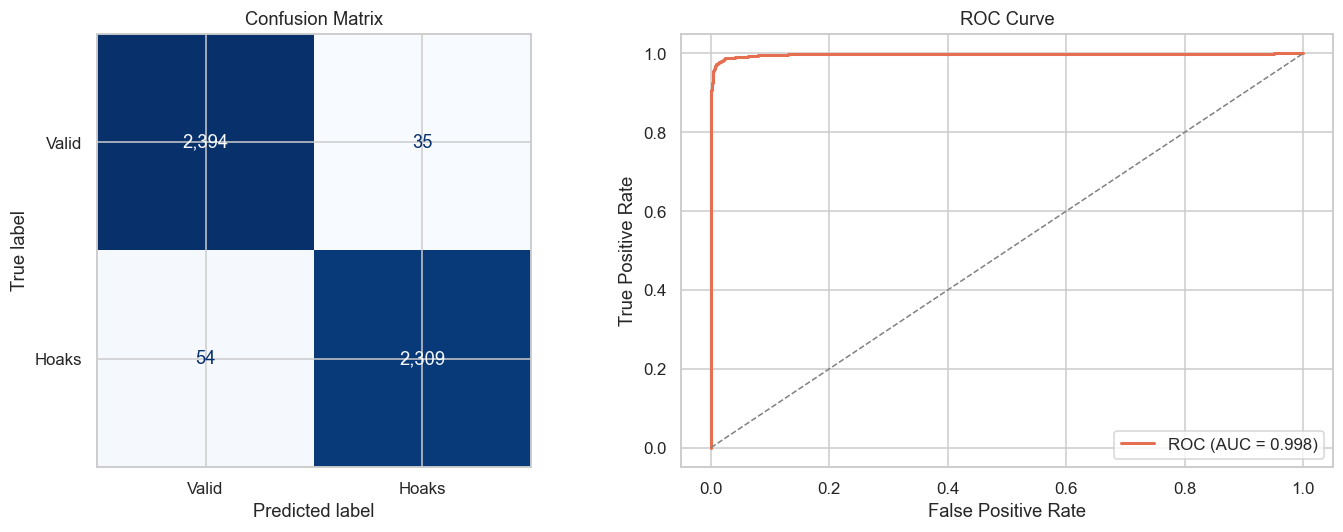

In [18]:
# Confusion Matrix + ROC Curve berdampingan
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Valid", "Hoaks"]).plot(
    cmap="Blues", values_format=",d", ax=ax[0], colorbar=False)
ax[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, color="#e76f51", lw=2, label=f"ROC (AUC = {auc(fpr, tpr):.3f})")
ax[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve"); ax[1].legend(loc="lower right")

plt.tight_layout(); plt.show()

## 1️⃣2️⃣ Analisis *Overfitting*
Membandingkan performa **train vs test**. Selisih besar (heuristik **> 5%**) menandakan model menghafal
data latih dan kurang menggeneralisasi.

In [19]:
# Metrik pada data latih
y_train_pred = svm_model.predict(X_train_vec)
train_acc = accuracy_score(y_train, y_train_pred)
train_f1  = f1_score(y_train, y_train_pred)
test_acc, test_f1 = acc, f1

overfit_tbl = pd.DataFrame({
    "Metric": ["Accuracy", "F1-score"],
    "Train":  [train_acc, train_f1],
    "Test":   [test_acc, test_f1],
})
overfit_tbl["Selisih (Train−Test)"] = overfit_tbl["Train"] - overfit_tbl["Test"]
display(overfit_tbl.round(4))

gap_acc = train_acc - test_acc
gap_f1  = train_f1 - test_f1
THRESH = 0.05

print("\n── Analisis Otomatis ──")
if gap_acc > THRESH or gap_f1 > THRESH:
    print(f"⚠️  POTENSI OVERFITTING: selisih Accuracy = {gap_acc:.3f}, F1 = {gap_f1:.3f} (> {THRESH:.0%}).")
    print("   Kemungkinan penyebab:")
    print("   • C terlalu besar → margin terlalu ketat menghafal data latih.")
    print("   • max_features TF-IDF terlalu tinggi → banyak fitur jarang/noise.")
    print("   • min_df terlalu rendah → menangkap kata sangat langka (mudah overfit).")
    print("   Mitigasi: turunkan C, perkecil max_features, naikkan min_df, tambah data,")
    print("            atau pakai kernel linear yang lebih sederhana.")
else:
    print(f"✅ Tidak ada indikasi overfitting berarti (selisih Acc={gap_acc:.3f}, F1={gap_f1:.3f} ≤ {THRESH:.0%}).")
    print("   Model menggeneralisasi dengan baik ke data yang belum pernah dilihat.")

,Metric,Train,Test,Selisih (Train−Test)
0,Accuracy,1.0,0.9814,0.0186
1,F1-score,1.0,0.9811,0.0189



── Analisis Otomatis ──
✅ Tidak ada indikasi overfitting berarti (selisih Acc=0.019, F1=0.019 ≤ 5%).
   Model menggeneralisasi dengan baik ke data yang belum pernah dilihat.


## 1️⃣3️⃣ Cross-Validation (5-fold)
`cross_val_score` 5-*fold* memberi estimasi performa yang lebih **stabil** dan tak bergantung pada satu
*split*. **Standar deviasi** yang kecil menandakan model **konsisten** antar-subset data.

In [20]:
# CV dijalankan pada seluruh data (ter-vektorisasi) memakai parameter terbaik.
# Untuk efisiensi, dipakai LinearSVC bila kernel terbaik = linear; selain itu SVC.
cv_estimator = (LinearSVC(C=best_params["C"], class_weight="balanced", random_state=RANDOM_STATE)
                if best_params["kernel"] == "linear"
                else SVC(**best_params, class_weight="balanced", random_state=RANDOM_STATE))

X_all_vec = vectorizer.transform(df["processed"])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("⏳ Menghitung 5-fold cross-validation…")
cv_scores = cross_val_score(cv_estimator, X_all_vec, df["label"],
                            cv=skf, scoring="accuracy", n_jobs=-1)

print(f"Skor per fold : {np.round(cv_scores, 4)}")
print(f"Mean accuracy : {cv_scores.mean():.4f}")
print(f"Std deviation : {cv_scores.std():.4f}")

if cv_scores.std() > 0.03:
    print("⚠️  Std cukup tinggi → performa model kurang stabil antar-fold "
          "(sensitif terhadap komposisi data). Pertimbangkan menambah data / regularisasi.")
else:
    print("✅ Std rendah → model stabil & konsisten di berbagai subset data.")

⏳ Menghitung 5-fold cross-validation…
Skor per fold : [0.9823 0.9852 0.9825 0.9808 0.9825]
Mean accuracy : 0.9826
Std deviation : 0.0014
✅ Std rendah → model stabil & konsisten di berbagai subset data.


## 1️⃣4️⃣ Learning Curve — Diagnosis Bias vs Variance
Kurva belajar menunjukkan skor *train* & *validation* seiring bertambahnya jumlah data:
* **Gap besar** train ≫ validation → **variance tinggi** (*overfitting*).
* **Kedua kurva rendah & berdekatan** → **bias tinggi** (*underfitting*).
* **Kedua kurva tinggi & konvergen** → keseimbangan yang sehat.

⏳ Menghitung learning curve…


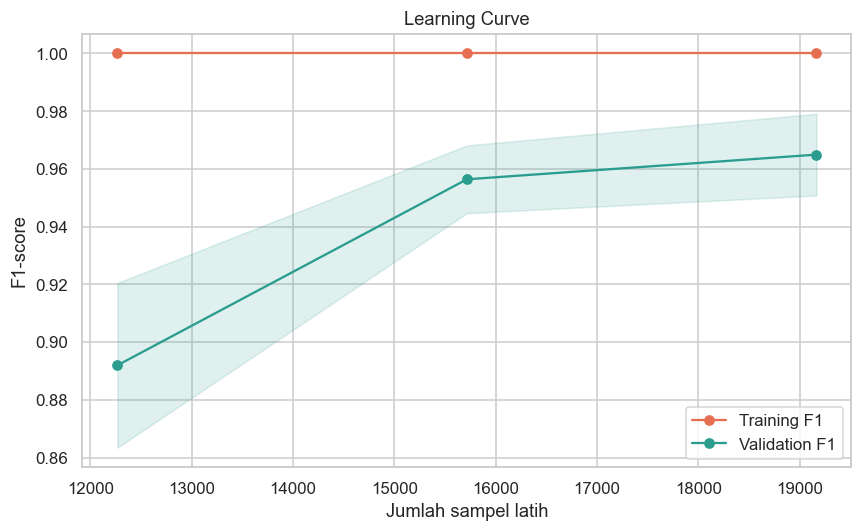

Gap akhir (train−val) : 0.035


In [21]:
print("⏳ Menghitung learning curve…")
lc_estimator = (LinearSVC(C=best_params["C"], class_weight="balanced", random_state=RANDOM_STATE)
                if best_params["kernel"] == "linear"
                else SVC(**best_params, class_weight="balanced", random_state=RANDOM_STATE))

train_sizes, train_scores, val_scores = learning_curve(
    lc_estimator, X_all_vec, df["label"],
    cv=5, scoring="f1", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=RANDOM_STATE,
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, tr_mean, "o-", color="#e76f51", label="Training F1")
plt.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#e76f51")
plt.plot(train_sizes, va_mean, "o-", color="#2a9d8f", label="Validation F1")
plt.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color="#2a9d8f")
plt.xlabel("Jumlah sampel latih"); plt.ylabel("F1-score")
plt.title("Learning Curve"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"Gap akhir (train−val) : {tr_mean[-1] - va_mean[-1]:.3f}")

## 1️⃣5️⃣ Feature Importance — Kata Paling Menentukan
Pada **SVM linear**, bobot `coef_` tiap fitur (kata) menunjukkan kontribusinya: koefisien **positif**
mendorong ke kelas **Hoaks (1)**, **negatif** ke kelas **Valid (0)**. Kita tampilkan **Top-20** untuk
masing-masing kelas.

> Jika kernel terbaik ternyata `rbf` (tak punya `coef_` yang bisa langsung dibaca), kita latih sebuah
> **`LinearSVC` sebagai model pendamping (*surrogate*)** pada fitur yang sama semata-mata untuk
> interpretasi. Ini tidak mengubah model final.

coef_ dari LinearSVC surrogate (model final memakai kernel rbf).


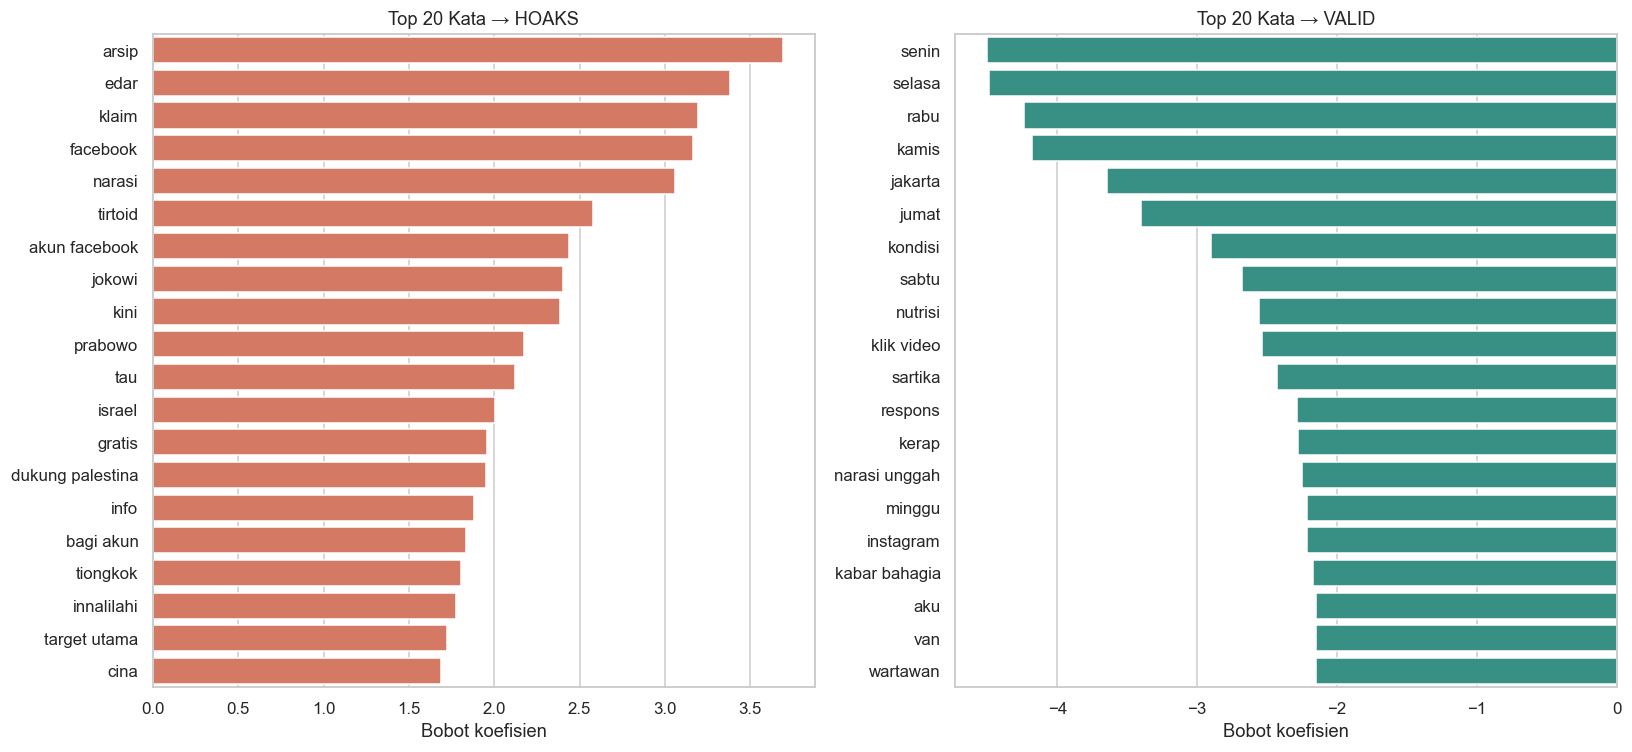

Top 10 indikator HOAKS : ['arsip', 'edar', 'klaim', 'facebook', 'narasi', 'tirtoid', 'akun facebook', 'jokowi', 'kini', 'prabowo']
Top 10 indikator VALID : ['senin', 'selasa', 'rabu', 'kamis', 'jakarta', 'jumat', 'kondisi', 'sabtu', 'nutrisi', 'klik video']


In [22]:
# Ambil koefisien dari model linear (langsung bila kernel linear, atau surrogate bila rbf).
if best_params["kernel"] == "linear":
    coef_source = svm_model                      # SVC linear mengekspos coef_
    note = "coef_ diambil dari model final (kernel linear)."
else:
    coef_source = LinearSVC(C=best_params["C"], class_weight="balanced",
                            random_state=RANDOM_STATE).fit(X_train_vec, y_train)
    note = "coef_ dari LinearSVC surrogate (model final memakai kernel rbf)."
print(note)

feature_names = np.array(vectorizer.get_feature_names_out())
coefs = coef_source.coef_
coefs = coefs.toarray() if hasattr(coefs, "toarray") else np.asarray(coefs)  # SVC linear -> sparse
coefs = coefs.ravel()

TOP_N = 20
top_hoax_idx  = np.argsort(coefs)[-TOP_N:][::-1]   # koef tertinggi -> Hoaks
top_valid_idx = np.argsort(coefs)[:TOP_N]          # koef terendah  -> Valid

top_hoax  = pd.DataFrame({"kata": feature_names[top_hoax_idx],  "bobot": coefs[top_hoax_idx]})
top_valid = pd.DataFrame({"kata": feature_names[top_valid_idx], "bobot": coefs[top_valid_idx]})

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
sns.barplot(data=top_hoax, y="kata", x="bobot", color="#e76f51", ax=ax[0])
ax[0].set_title(f"Top {TOP_N} Kata → HOAKS"); ax[0].set_xlabel("Bobot koefisien"); ax[0].set_ylabel("")
sns.barplot(data=top_valid, y="kata", x="bobot", color="#2a9d8f", ax=ax[1])
ax[1].set_title(f"Top {TOP_N} Kata → VALID"); ax[1].set_xlabel("Bobot koefisien"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

print("Top 10 indikator HOAKS :", list(top_hoax["kata"].head(10)))
print("Top 10 indikator VALID :", list(top_valid["kata"].head(10)))

## 1️⃣6️⃣ & 1️⃣8️⃣ Simpan Model + Pipeline Reusable
Kita simpan tiga artefak dengan `joblib`:
1. `tfidf_vectorizer.pkl` — vektorizer TF-IDF.
2. `svm_model.pkl` — model SVM final.
3. `hoax_pipeline.pkl` — **`Pipeline`** gabungan **TF-IDF → SVM** yang bisa dipakai ulang **tanpa
   memvektorisasi manual** (menerima teks yang sudah di-*preprocess*).

`preprocess()` (cleaning + stemming) tetap di luar `Pipeline` karena bergantung pada Sastrawi; fungsi
`predict_news()` di bawah menyatukan keduanya menjadi alur *end-to-end* dari teks mentah.

In [23]:
# Pipeline reusable: TF-IDF + SVM final (dilatih ulang menyatu agar konsisten).
hoax_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**best_tfidf_params)),
    ("svm",   SVC(**best_params, class_weight="balanced",
                  probability=True, random_state=RANDOM_STATE)),
])
hoax_pipeline.fit(X_train, y_train)   # fit pada teks terproses

# Simpan seluruh artefak
joblib.dump(vectorizer,    MODELS_DIR / "tfidf_vectorizer.pkl")
joblib.dump(svm_model,     MODELS_DIR / "svm_model.pkl")
joblib.dump(hoax_pipeline, MODELS_DIR / "hoax_pipeline.pkl")

print("✅ Artefak tersimpan di folder 'models/':")
for f in ["tfidf_vectorizer.pkl", "svm_model.pkl", "hoax_pipeline.pkl"]:
    p = MODELS_DIR / f
    print(f"   • {f:<24} ({p.stat().st_size/1024:,.1f} KB)")

✅ Artefak tersimpan di folder 'models/':
   • tfidf_vectorizer.pkl     (518.2 KB)
   • svm_model.pkl            (3,905.8 KB)
   • hoax_pipeline.pkl        (4,423.8 KB)


## 1️⃣7️⃣ Fungsi Prediksi — `predict_news(text)`
Menerima **teks berita mentah**, menjalankan **cleaning → preprocessing → stemming → vektorisasi →
prediksi**, lalu mengembalikan **label** dan **confidence**. Confidence dihitung dari `predict_proba()`
(diaktifkan via `probability=True`).

In [24]:
def predict_news(text, pipeline=hoax_pipeline, return_dict=False, verbose=True):
    # Prediksi satu teks berita mentah -> label + confidence.
    processed = preprocess(clean_text(text))     # cleaning + stopword + stemming
    if not processed.strip():
        if verbose:
            print("⚠️  Teks kosong setelah preprocessing; tidak dapat diprediksi.")
        return {"label": None, "confidence": 0.0} if return_dict else None

    proba = pipeline.predict_proba([processed])[0]
    pred  = int(np.argmax(proba))
    label = "Hoaks" if pred == 1 else "Valid"
    confidence = float(proba[pred] * 100)

    if verbose:
        icon = "🚩" if pred == 1 else "✅"
        print(f"{icon} Label      : {label}")
        print(f"   Confidence : {confidence:.2f}%")
    return {"label": label, "confidence": round(confidence, 2)} if return_dict else None


# Uji dengan beberapa contoh
print("① ", end=""); predict_news(
    "SEBARKAN! Pemerintah bagikan token listrik gratis 3 bulan, klik link ini sekarang sebelum dihapus!")
print("\n② ", end=""); predict_news(
    "Menteri Pertahanan meresmikan program pembangunan infrastruktur di Jawa Timur dalam acara kenegaraan resmi.")

① 🚩 Label      : Hoaks
   Confidence : 100.00%

② 🚩 Label      : Hoaks
   Confidence : 85.32%


## 1️⃣9️⃣ & 2️⃣0️⃣ Update Dataset Otomatis — `append_new_dataset(folder)`
Alur pembaruan tanpa mengubah kode:
1. Taruh CSV baru hasil *scraping* (mis. `cnn_cleaned.csv`, `tempo_cleaned.csv`) di sebuah folder.
2. Panggil `append_new_dataset("folder_baru")`.

Fungsi ini akan: **membaca semua CSV baru → menormalkan → menggabung dengan data lama → menghapus
duplikat berdasarkan judul & isi → menyimpan dataset gabungan terbaru → melatih ulang model & vektorizer
→ menyimpan artefak baru** secara otomatis.

> Karena `load_dataset()` sudah berbasis `glob`, alternatif paling sederhana adalah **menaruh CSV baru
> langsung di `DATA_DIR` lalu menjalankan ulang notebook dari atas** — semuanya ikut terbaca otomatis.

In [25]:
COMBINED_DATASET_PATH = MODELS_DIR / "combined_dataset_latest.csv"


def retrain_and_save(full_df):
    # Latih ulang pipeline pada seluruh data terproses lalu simpan artefak. Kembalikan pipeline baru.
    processed_df = build_processed(full_df, force=True)
    Xf, yf = processed_df["processed"], processed_df["label"]
    Xtr, Xte, ytr, yte = train_test_split(
        Xf, yf, test_size=0.20, stratify=yf, random_state=RANDOM_STATE)

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**best_tfidf_params)),
        ("svm",   SVC(**best_params, class_weight="balanced",
                      probability=True, random_state=RANDOM_STATE)),
    ])
    pipe.fit(Xtr, ytr)
    new_f1 = f1_score(yte, pipe.predict(Xte))

    joblib.dump(pipe, MODELS_DIR / "hoax_pipeline.pkl")
    joblib.dump(pipe.named_steps["tfidf"], MODELS_DIR / "tfidf_vectorizer.pkl")
    joblib.dump(pipe.named_steps["svm"],   MODELS_DIR / "svm_model.pkl")
    print(f"✅ Model dilatih ulang & disimpan. F1 (test) = {new_f1:.4f}")
    return pipe


def append_new_dataset(folder, base_df=None, retrain=True):
    # Gabungkan CSV baru dari `folder` ke dataset lama, dedup, simpan, lalu latih ulang.
    if base_df is None:
        base_df = df[["title", "text", "label", "source"]].copy()

    new_df = load_dataset(folder, verbose=True)               # baca semua CSV baru
    combined = pd.concat([base_df, new_df], ignore_index=True)

    before = len(combined)
    combined = combined.drop_duplicates(subset=["title", "text"]).reset_index(drop=True)
    print(f"\nGabungan: {before:,} → {len(combined):,} baris "
          f"({before - len(combined):,} duplikat dibuang berdasarkan judul & isi).")

    combined.to_csv(COMBINED_DATASET_PATH, index=False)
    print(f"💾 Dataset terbaru disimpan: {COMBINED_DATASET_PATH}")

    new_pipeline = retrain_and_save(combined) if retrain else None
    return combined, new_pipeline


# Contoh pemakaian (uncomment saat ada folder data baru):
# combined_df, hoax_pipeline = append_new_dataset("scraping_baru")
print("Fungsi append_new_dataset() siap digunakan.")
print("Contoh: combined_df, hoax_pipeline = append_new_dataset('scraping_baru')")

Fungsi append_new_dataset() siap digunakan.
Contoh: combined_df, hoax_pipeline = append_new_dataset('scraping_baru')


## 2️⃣1️⃣ Visualisasi Ringkasan
Rangkuman visual kunci dalam satu tempat: **distribusi kelas**, **confusion matrix**, **ROC**, dan
**distribusi panjang berita** per kelas. (Learning curve & feature importance sudah ditampilkan di atas.)

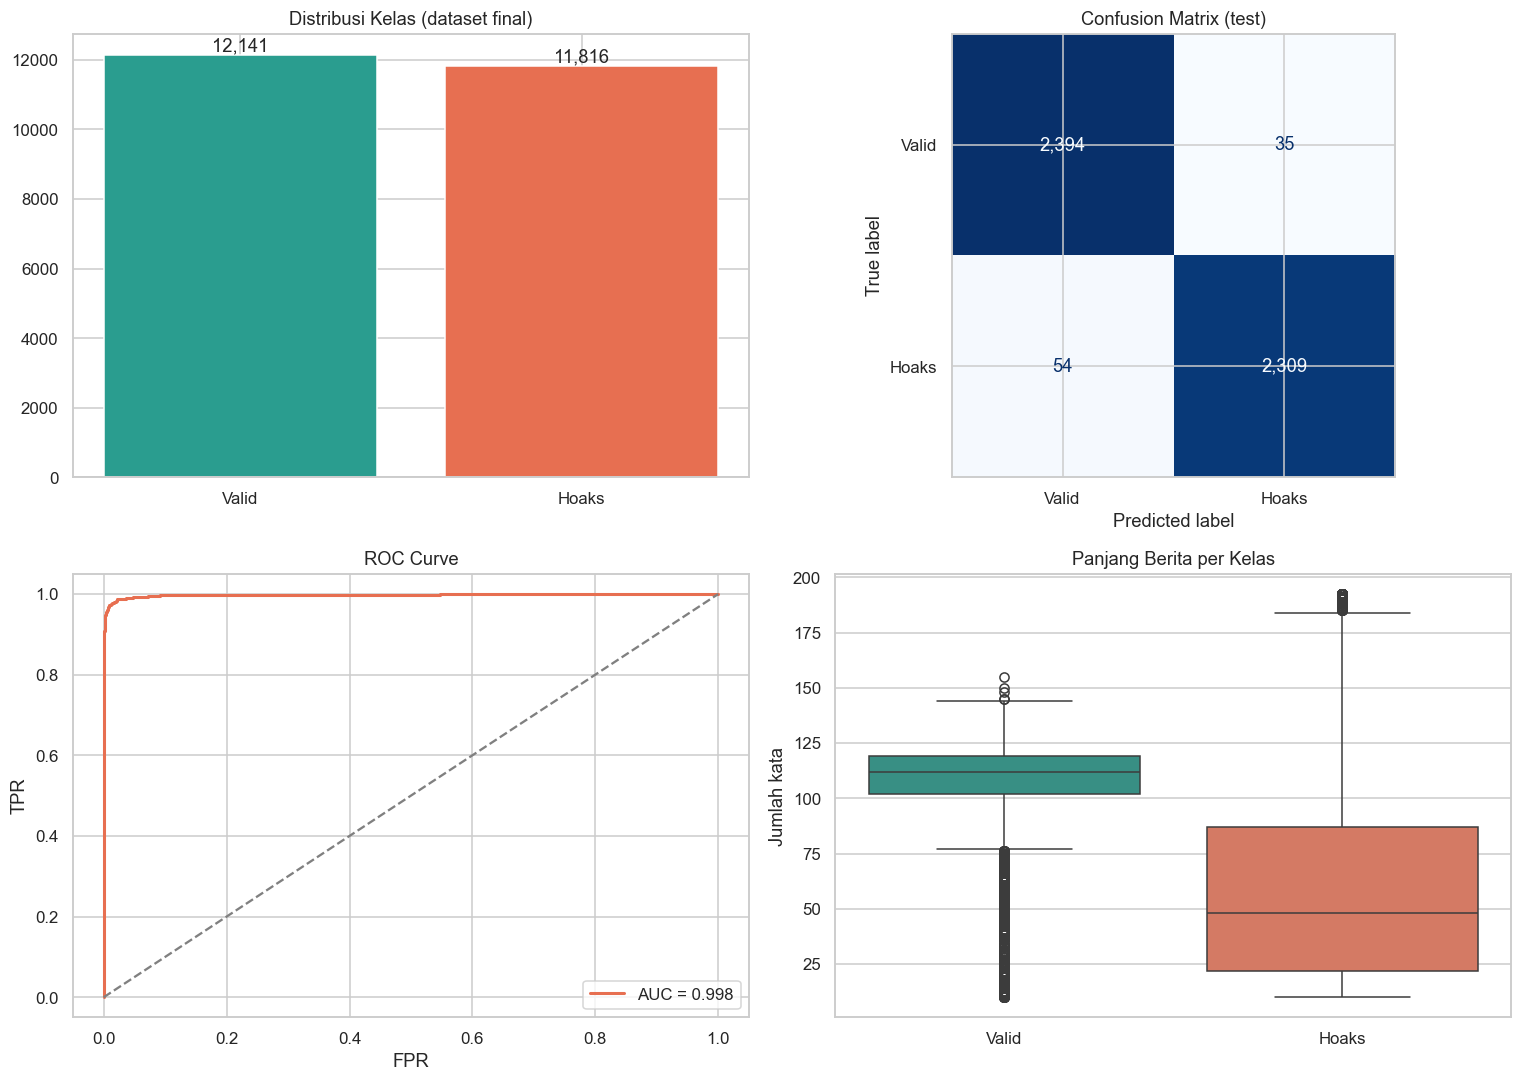

In [26]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# (a) Distribusi kelas
vc = df["label"].map({0: "Valid", 1: "Hoaks"}).value_counts()
ax[0, 0].bar(vc.index, vc.values, color=["#2a9d8f", "#e76f51"])
ax[0, 0].set_title("Distribusi Kelas (dataset final)")
for i, v in enumerate(vc.values):
    ax[0, 0].text(i, v, f"{v:,}", ha="center", va="bottom")

# (b) Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Valid", "Hoaks"]).plot(
    cmap="Blues", values_format=",d", ax=ax[0, 1], colorbar=False)
ax[0, 1].set_title("Confusion Matrix (test)")

# (c) ROC
ax[1, 0].plot(fpr, tpr, color="#e76f51", lw=2, label=f"AUC = {auc(fpr, tpr):.3f}")
ax[1, 0].plot([0, 1], [0, 1], "--", color="grey")
ax[1, 0].set_title("ROC Curve"); ax[1, 0].set_xlabel("FPR"); ax[1, 0].set_ylabel("TPR")
ax[1, 0].legend(loc="lower right")

# (d) Panjang berita per kelas
clip = df["n_words"].clip(upper=df["n_words"].quantile(0.99))
tmp = pd.DataFrame({"n_words": clip, "Label": df["label"].map({0: "Valid", 1: "Hoaks"})})
sns.boxplot(data=tmp, x="Label", y="n_words", palette=["#2a9d8f", "#e76f51"], ax=ax[1, 1])
ax[1, 1].set_title("Panjang Berita per Kelas"); ax[1, 1].set_xlabel(""); ax[1, 1].set_ylabel("Jumlah kata")

plt.tight_layout(); plt.show()

## 2️⃣2️⃣ Kesimpulan & Analisis Hasil

**Ringkasan pipeline.** Notebook memuat seluruh alur *end-to-end*: pembacaan multi-CSV otomatis →
pembersihan & preprocessing Bahasa Indonesia (Sastrawi) → TF-IDF → SVM ter-*tuning* → evaluasi menyeluruh
→ penyimpanan artefak → fungsi prediksi & pembaruan dataset.

**Interpretasi hasil.**
* **Akurasi & F1** pada data uji (lihat Bagian 11) menunjukkan kemampuan pemisahan Hoaks vs Valid; **AUC**
  yang tinggi menandakan pemeringkatan probabilitas yang baik.
* **Analisis *overfitting*** (Bagian 12) membandingkan train vs test; peringatan muncul otomatis bila
  selisih > 5%. Ini pengingat untuk menurunkan `C` / `max_features` bila terjadi.
* **Cross-validation** (Bagian 13) mengukur kestabilan; std kecil = model konsisten.
* **Learning curve** (Bagian 14) mendiagnosis bias/variance; kurva yang konvergen di skor tinggi = sehat.
* **Feature importance** (Bagian 15) memberi transparansi: kata-kata pemicu tiap kelas masuk akal secara
  jurnalistik (mis. penanda klaim/ajakan sebar pada kelas Hoaks).

**Alasan pilihan desain.**
* **TF-IDF** — representasi teks ringan, kuat, dan interpretable.
* **Kernel** — `linear` diprioritaskan karena teks umumnya linear-separable & memberi bobot yang bisa
  dibaca; `rbf` tetap diuji lewat GridSearch sebagai pembanding.
* **`class_weight='balanced'`** — menangani ketimpangan tanpa menduplikasi data.

**Reusability & pembaruan.** Berkat `glob` + deteksi kolom otomatis + `append_new_dataset()`, menambah
sumber berita baru (CNN, Tempo, Tribun, dsb.) cukup dengan menaruh CSV dan menjalankan ulang — **tanpa
mengedit kode**.

**Output akhir yang dihasilkan:** `svm_model.pkl`, `tfidf_vectorizer.pkl`, `hoax_pipeline.pkl`,
fungsi `predict_news()` & `append_new_dataset()`, serta visualisasi evaluasi lengkap.

**Catatan keterbatasan.** Karakteristik dataset (mis. sumber Valid berasal dari situs kredibel dan Hoaks
dari basis data klarifikasi) dapat membuat model sebagian belajar **gaya/sumber**, bukan semata *kebenaran*
faktual. Untuk *deployment* nyata, evaluasi lintas-domain dan pembaruan berkala sangat dianjurkan.

---
*Selesai. Selamat bereksperimen! 🚀*